# Build Dataset Info
Summarizes key statistics from a given build dataset for paper reporting.

Analyzes **input** (S = source/set params, X = read params) and **target** (Y) arrays.

Key metrics:
- Sequence length statistics (before padding): min, max, mean, median
- Missing value statistics (excluding padding tokens)
- Vocabulary sizes, feature schemas
- Train/test split info

In [1]:
# =============================================================================
# SETUP & CONFIGURATION
# =============================================================================
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join, exists

ROOT_DIR = "../"
sys.path.append(ROOT_DIR)
from proT_pipeline.labels import *

# ── Configure dataset ──────────────────────────────────────────────────────
dataset_id = "dyconex_251117"
# ───────────────────────────────────────────────────────────────────────────

INPUT_DIR, OUTPUT_DIR, CONTROL_DIR = get_input_dirs(ROOT_DIR, dataset_id)
DS_DIR = join(OUTPUT_DIR, f"ds_{dataset_id}")

print(f"Build: {dataset_id}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Dataset dir: {DS_DIR}")

Build: dyconex_251117
Output dir: ../data\builds\dyconex_251117\output
Dataset dir: ../data\builds\dyconex_251117\output\ds_dyconex_251117


In [2]:
# =============================================================================
# LOAD DATA & METADATA
# =============================================================================

# Load compressed dataset
data = np.load(join(DS_DIR, full_data_label), allow_pickle=True)
print("Keys in data.npz:", list(data.keys()))

has_source = 's' in data
X = data['x']  # Input (Read params)
Y = data['y']  # Target
S = data['s'] if has_source else None  # Source (Set params)

print(f"\nX (input)  shape: {X.shape}")
if has_source:
    print(f"S (source) shape: {S.shape}")
print(f"Y (target) shape: {Y.shape}")

Keys in data.npz: ['x', 'y']

X (input)  shape: (1920, 1023, 12)
Y (target) shape: (1920, 400, 9)


In [3]:
# Load features dictionary
with open(join(OUTPUT_DIR, feat_dict_filename), "r") as f:
    feat_dict = json.load(f)

print("Input features:")
for idx, name in sorted(feat_dict["input"].items(), key=lambda x: int(x[0])):
    print(f"  [{idx}] {name}")

print("\nTarget features:")
for idx, name in sorted(feat_dict["target"].items(), key=lambda x: int(x[0])):
    print(f"  [{idx}] {name}")

if "source" in feat_dict:
    print("\nSource features:")
    for idx, name in sorted(feat_dict["source"].items(), key=lambda x: int(x[0])):
        print(f"  [{idx}] {name}")

Input features:
  [0] group
  [1] process
  [2] occurrence
  [3] step
  [4] variable
  [5] value_norm
  [6] order
  [7] year
  [8] month
  [9] day
  [10] hour
  [11] minute

Target features:
  [0] group
  [1] position
  [2] variable
  [3] value
  [4] year
  [5] month
  [6] day
  [7] hour
  [8] minute


In [4]:
# Load vocabularies
def load_json(filepath):
    if exists(filepath):
        with open(filepath, "r") as f:
            return json.load(f)
    return None

vocab_process  = load_json(join(OUTPUT_DIR, process_dict_filename))
vocab_group    = load_json(join(OUTPUT_DIR, group_dict_filename))
vocab_step     = load_json(join(OUTPUT_DIR, step_dict_filename))
vocab_var_input  = load_json(join(OUTPUT_DIR, var_dict_filename + "_input"))
vocab_var_source = load_json(join(OUTPUT_DIR, var_dict_filename + "_source"))
vocab_var_trg    = load_json(join(OUTPUT_DIR, var_dict_filename + "_trg"))

print("Vocabulary sizes:")
print(f"  Processes:          {len(vocab_process) if vocab_process else 'N/A'}")
print(f"  Groups (samples):   {len(vocab_group) if vocab_group else 'N/A'}")
print(f"  Steps:              {sum(len(v) for v in vocab_step.values()) if vocab_step else 'N/A'} (across {len(vocab_step) if vocab_step else 0} process-occurrences)")
print(f"  Variables (input):  {len(vocab_var_input) if vocab_var_input else 'N/A'}")
print(f"  Variables (source): {len(vocab_var_source) if vocab_var_source else 'N/A'}")
print(f"  Variables (target): {len(vocab_var_trg) if vocab_var_trg else 'N/A'}")

Vocabulary sizes:
  Processes:          5
  Groups (samples):   1920
  Steps:              32 (across 14 process-occurrences)
  Variables (input):  372
  Variables (source): N/A
  Variables (target): 2


---
# 1. Dataset Overview

In [5]:
n_samples = X.shape[0]

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Build ID:              {dataset_id}")
print(f"Number of samples:     {n_samples}")
print(f"")
print(f"X (input/read):        {X.shape}  → ({X.shape[0]} samples × {X.shape[1]} max_seq_len × {X.shape[2]} features)")
if has_source:
    print(f"S (source/set):        {S.shape}  → ({S.shape[0]} samples × {S.shape[1]} max_seq_len × {S.shape[2]} features)")
print(f"Y (target):            {Y.shape}  → ({Y.shape[0]} samples × {Y.shape[1]} max_seq_len × {Y.shape[2]} features)")
print(f"")
print(f"Processes:             {list(vocab_process.keys()) if vocab_process else 'N/A'}")
print(f"Target variables:      {list(vocab_var_trg.keys()) if vocab_var_trg else 'N/A'}")

DATASET OVERVIEW
Build ID:              dyconex_251117
Number of samples:     1920

X (input/read):        (1920, 1023, 12)  → (1920 samples × 1023 max_seq_len × 12 features)
Y (target):            (1920, 400, 9)  → (1920 samples × 400 max_seq_len × 9 features)

Processes:             ['Laser', 'Plasma', 'Galvanic', 'Multibond', 'Microetch']
Target variables:      ['delta_A_norm', 'delta_B_norm']


---
# 2. Sequence Length Statistics

Compute the **actual sequence length** (before padding) for each sample in S, X, and Y.

**Padding detection:**
- **X / S**: `pandas_to_numpy_ds` pads with `NaN`. A token is padding if all features are `NaN`.
- **Y**: position feature (index 1) is 0 for padding tokens (0 is reserved for padding embeddings).

In [6]:
def get_seq_lengths_input(arr):
    """
    Get actual sequence length per sample for input/source arrays.
    Padding tokens have all-NaN features (from pandas_to_numpy_ds).
    """
    # A token is NOT padding if at least one feature is not NaN
    not_padding = ~np.isnan(arr).all(axis=2)  # shape: (n_samples, max_seq_len)
    return not_padding.sum(axis=1)  # shape: (n_samples,)


def get_seq_lengths_target(arr, position_idx=1):
    """
    Get actual sequence length per sample for target array.
    Padding tokens have position == 0 (reserved for padding embeddings)
    or NaN.
    """
    position = arr[:, :, position_idx]  # shape: (n_samples, max_seq_len)
    # A token is NOT padding if position > 0 and not NaN
    not_padding = (position > 0) & (~np.isnan(position))
    return not_padding.sum(axis=1)  # shape: (n_samples,)


def seq_len_stats(lengths, name):
    """Print summary statistics for sequence lengths."""
    stats = {
        "Array": name,
        "Min": int(np.min(lengths)),
        "Max": int(np.max(lengths)),
        "Mean": f"{np.mean(lengths):.1f}",
        "Median": f"{np.median(lengths):.1f}",
        "Std": f"{np.std(lengths):.1f}",
        "N unique": int(len(np.unique(lengths))),
    }
    return stats


# Compute sequence lengths
seq_len_X = get_seq_lengths_input(X)
seq_len_Y = get_seq_lengths_target(Y)
seq_len_S = get_seq_lengths_input(S) if has_source else None

# Build summary table
rows = [seq_len_stats(seq_len_X, "X (input/read)")]
if has_source:
    rows.append(seq_len_stats(seq_len_S, "S (source/set)"))
rows.append(seq_len_stats(seq_len_Y, "Y (target)"))

df_seq_stats = pd.DataFrame(rows).set_index("Array")
print("SEQUENCE LENGTH STATISTICS (before padding)")
print("=" * 60)
display(df_seq_stats)

SEQUENCE LENGTH STATISTICS (before padding)


,Min,Max,Mean,Median,Std,N unique
Array,,,,,,
X (input/read),111,1023,809.5,811.0,174.0,131
Y (target),200,400,399.7,400.0,6.2,11


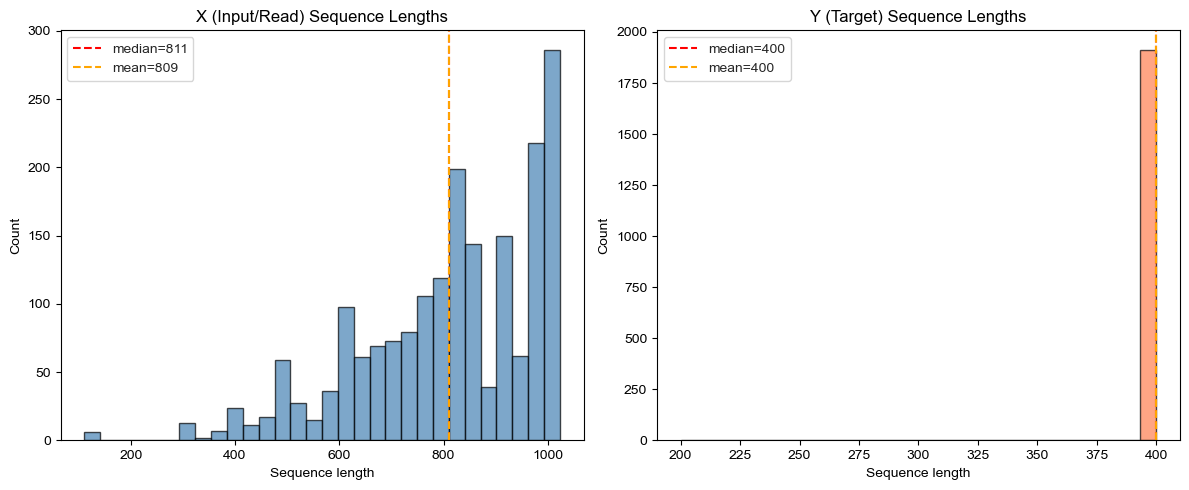

In [7]:
# Sequence length distribution — Input X
fig, axes = plt.subplots(1, 3 if has_source else 2, figsize=(6 * (3 if has_source else 2), 5))
sns.set_style("whitegrid")

ax_idx = 0

# X histogram
axes[ax_idx].hist(seq_len_X, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[ax_idx].axvline(np.median(seq_len_X), color="red", linestyle="--", label=f"median={np.median(seq_len_X):.0f}")
axes[ax_idx].axvline(np.mean(seq_len_X), color="orange", linestyle="--", label=f"mean={np.mean(seq_len_X):.0f}")
axes[ax_idx].set_title("X (Input/Read) Sequence Lengths")
axes[ax_idx].set_xlabel("Sequence length")
axes[ax_idx].set_ylabel("Count")
axes[ax_idx].legend()
ax_idx += 1

# S histogram
if has_source:
    axes[ax_idx].hist(seq_len_S, bins=30, edgecolor="black", alpha=0.7, color="seagreen")
    axes[ax_idx].axvline(np.median(seq_len_S), color="red", linestyle="--", label=f"median={np.median(seq_len_S):.0f}")
    axes[ax_idx].axvline(np.mean(seq_len_S), color="orange", linestyle="--", label=f"mean={np.mean(seq_len_S):.0f}")
    axes[ax_idx].set_title("S (Source/Set) Sequence Lengths")
    axes[ax_idx].set_xlabel("Sequence length")
    axes[ax_idx].set_ylabel("Count")
    axes[ax_idx].legend()
    ax_idx += 1

# Y histogram
axes[ax_idx].hist(seq_len_Y, bins=30, edgecolor="black", alpha=0.7, color="coral")
axes[ax_idx].axvline(np.median(seq_len_Y), color="red", linestyle="--", label=f"median={np.median(seq_len_Y):.0f}")
axes[ax_idx].axvline(np.mean(seq_len_Y), color="orange", linestyle="--", label=f"mean={np.mean(seq_len_Y):.0f}")
axes[ax_idx].set_title("Y (Target) Sequence Lengths")
axes[ax_idx].set_xlabel("Sequence length")
axes[ax_idx].set_ylabel("Count")
axes[ax_idx].legend()

plt.tight_layout()
plt.show()

In [8]:
# Detailed sequence length distribution (value counts)
print("X (input) sequence length distribution:")
x_vc = pd.Series(seq_len_X).value_counts().sort_index()
x_vc.index.name = "seq_len"
x_vc.name = "count"
display(x_vc.to_frame().T)

if has_source:
    print("\nS (source) sequence length distribution:")
    s_vc = pd.Series(seq_len_S).value_counts().sort_index()
    s_vc.index.name = "seq_len"
    s_vc.name = "count"
    display(s_vc.to_frame().T)

print("\nY (target) sequence length distribution:")
y_vc = pd.Series(seq_len_Y).value_counts().sort_index()
y_vc.index.name = "seq_len"
y_vc.name = "count"
display(y_vc.to_frame().T)

X (input) sequence length distribution:


seq_len,111,127,305,312,330,344,372,380,381,398,...,972,973,980,981,983,989,991,1007,1015,1023
count,1,5,10,3,1,1,5,1,1,1,...,6,8,18,11,2,163,10,8,54,224



Y (target) sequence length distribution:


seq_len,200,236,335,363,381,383,384,390,397,399,400
count,1,1,1,1,1,1,1,1,1,2,1909


---
# 3. Missing Value Statistics (Excluding Padding)

Counts `NaN` values in the **value feature** of non-padding tokens only:
- **X / S**: `value_norm` at feature index 5
- **Y**: `value` at feature index 3

In [9]:
def get_non_padding_mask_input(arr):
    """Boolean mask: True for non-padding tokens in input/source arrays."""
    return ~np.isnan(arr).all(axis=2)


def get_non_padding_mask_target(arr, position_idx=1):
    """Boolean mask: True for non-padding tokens in target array."""
    position = arr[:, :, position_idx]
    return (position > 0) & (~np.isnan(position))


def missing_value_stats(arr, mask, value_idx, name):
    """
    Compute missing value statistics for a given array.
    
    Args:
        arr: numpy array (n_samples, max_seq_len, n_features)
        mask: boolean mask for non-padding tokens (n_samples, max_seq_len)
        value_idx: feature index for the value column
        name: display name
    """
    values = arr[:, :, value_idx]  # (n_samples, max_seq_len)
    
    # Total non-padding tokens
    total_tokens = mask.sum()
    
    # Missing values among non-padding tokens
    missing_mask = np.isnan(values) & mask
    total_missing = missing_mask.sum()
    
    # Per-sample statistics
    per_sample_tokens = mask.sum(axis=1)
    per_sample_missing = missing_mask.sum(axis=1)
    per_sample_pct = np.where(
        per_sample_tokens > 0,
        per_sample_missing / per_sample_tokens * 100,
        0
    )
    
    overall_pct = total_missing / total_tokens * 100 if total_tokens > 0 else 0
    
    return {
        "Array": name,
        "Total tokens (excl. padding)": int(total_tokens),
        "Missing tokens": int(total_missing),
        "Missing %": f"{overall_pct:.3f}%",
        "Per-sample missing % (mean)": f"{np.mean(per_sample_pct):.3f}%",
        "Per-sample missing % (max)": f"{np.max(per_sample_pct):.3f}%",
        "Samples with any missing": int((per_sample_missing > 0).sum()),
    }, per_sample_pct


# Compute masks
mask_X = get_non_padding_mask_input(X)
mask_Y = get_non_padding_mask_target(Y)
mask_S = get_non_padding_mask_input(S) if has_source else None

# Compute stats (value_norm at index 5 for X/S, value at index 3 for Y)
rows_missing = []
stats_X, pct_X = missing_value_stats(X, mask_X, value_idx=5, name="X (input/read)")
rows_missing.append(stats_X)

if has_source:
    stats_S, pct_S = missing_value_stats(S, mask_S, value_idx=5, name="S (source/set)")
    rows_missing.append(stats_S)

stats_Y, pct_Y = missing_value_stats(Y, mask_Y, value_idx=3, name="Y (target)")
rows_missing.append(stats_Y)

df_missing = pd.DataFrame(rows_missing).set_index("Array")
print("MISSING VALUE STATISTICS (excluding padding tokens)")
print("=" * 60)
display(df_missing)

MISSING VALUE STATISTICS (excluding padding tokens)


,Total tokens (excl. padding),Missing tokens,Missing %,Per-sample missing % (mean),Per-sample missing % (max),Samples with any missing
Array,,,,,,
X (input/read),1554196,113613,7.310%,7.259%,25.612%,1920
Y (target),767467,13160,1.715%,1.737%,90.250%,120


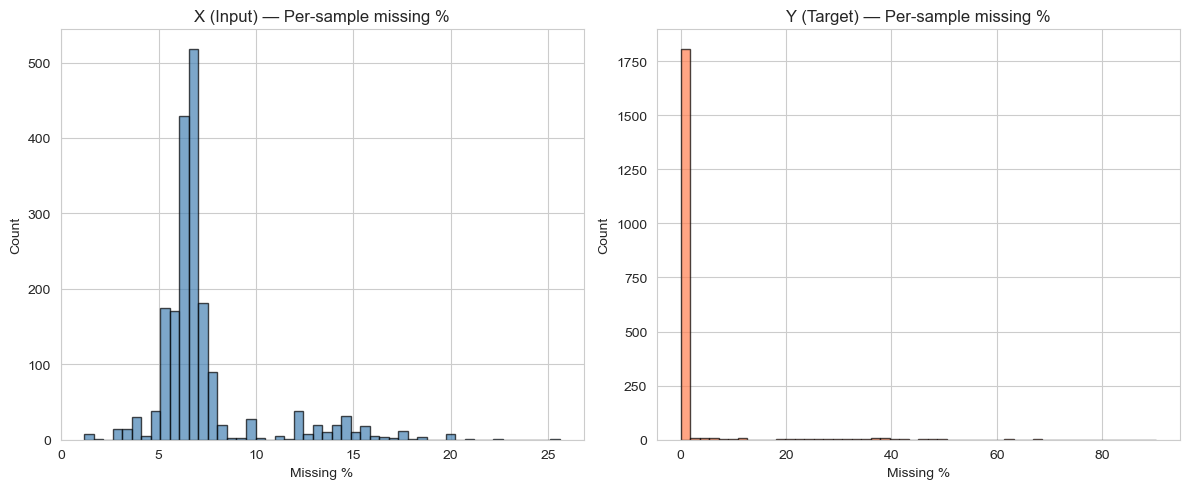

In [10]:
# Per-sample missing value distribution
fig, axes = plt.subplots(1, 3 if has_source else 2, figsize=(6 * (3 if has_source else 2), 5))

ax_idx = 0

axes[ax_idx].hist(pct_X, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[ax_idx].set_title("X (Input) — Per-sample missing %")
axes[ax_idx].set_xlabel("Missing %")
axes[ax_idx].set_ylabel("Count")
ax_idx += 1

if has_source:
    axes[ax_idx].hist(pct_S, bins=50, edgecolor="black", alpha=0.7, color="seagreen")
    axes[ax_idx].set_title("S (Source) — Per-sample missing %")
    axes[ax_idx].set_xlabel("Missing %")
    axes[ax_idx].set_ylabel("Count")
    ax_idx += 1

axes[ax_idx].hist(pct_Y, bins=50, edgecolor="black", alpha=0.7, color="coral")
axes[ax_idx].set_title("Y (Target) — Per-sample missing %")
axes[ax_idx].set_xlabel("Missing %")
axes[ax_idx].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 3.1 Missing Values by Process (Input X)
Analyze missing values broken down by process for the input array.

In [11]:
# Missing values by process (feature index 1 = process)
process_idx = 1
value_idx = 5

# Invert process vocabulary for readable names
inv_process_vocab = {v: k for k, v in vocab_process.items()} if vocab_process else {}

process_missing_rows = []
for proc_id in sorted(inv_process_vocab.keys()):
    proc_name = inv_process_vocab[proc_id]
    # Mask: non-padding AND belongs to this process
    proc_mask = mask_X & (X[:, :, process_idx] == proc_id)
    total = proc_mask.sum()
    if total > 0:
        missing = (np.isnan(X[:, :, value_idx]) & proc_mask).sum()
        process_missing_rows.append({
            "Process": proc_name,
            "Tokens": int(total),
            "Missing": int(missing),
            "Missing %": f"{missing / total * 100:.3f}%"
        })

if process_missing_rows:
    df_proc_missing = pd.DataFrame(process_missing_rows).set_index("Process")
    print("Missing values by process (X):")
    display(df_proc_missing)

Missing values by process (X):


,Tokens,Missing,Missing %
Process,,,
Laser,69672,12784,18.349%
Plasma,233361,11115,4.763%
Galvanic,755254,78917,10.449%
Multibond,351307,6446,1.835%
Microetch,144602,4351,3.009%


---
# 4. Train/Test Split Summary

In [12]:
train_path = join(DS_DIR, train_data_label)
test_path = join(DS_DIR, test_data_label)

if exists(train_path) and exists(test_path):
    train_data = np.load(train_path, allow_pickle=True)
    test_data = np.load(test_path, allow_pickle=True)
    
    X_train = train_data['x']
    Y_train = train_data['y']
    X_test = test_data['x']
    Y_test = test_data['y']
    
    S_train = train_data['s'] if 's' in train_data else None
    S_test = test_data['s'] if 's' in test_data else None
    
    n_train = X_train.shape[0]
    n_test = X_test.shape[0]
    n_total = n_train + n_test
    
    print("TRAIN/TEST SPLIT")
    print("=" * 60)
    print(f"Total samples:  {n_total}")
    print(f"Train samples:  {n_train} ({n_train/n_total*100:.1f}%)")
    print(f"Test samples:   {n_test} ({n_test/n_total*100:.1f}%)")
    print(f"")
    print(f"Train X: {X_train.shape}, Y: {Y_train.shape}" + (f", S: {S_train.shape}" if S_train is not None else ""))
    print(f"Test  X: {X_test.shape},  Y: {Y_test.shape}" + (f",  S: {S_test.shape}" if S_test is not None else ""))
    
    # Sequence length comparison
    seq_X_train = get_seq_lengths_input(X_train)
    seq_X_test = get_seq_lengths_input(X_test)
    seq_Y_train = get_seq_lengths_target(Y_train)
    seq_Y_test = get_seq_lengths_target(Y_test)
    
    print(f"\nInput seq len — Train: mean={np.mean(seq_X_train):.1f}, median={np.median(seq_X_train):.0f} | Test: mean={np.mean(seq_X_test):.1f}, median={np.median(seq_X_test):.0f}")
    print(f"Target seq len — Train: mean={np.mean(seq_Y_train):.1f}, median={np.median(seq_Y_train):.0f} | Test: mean={np.mean(seq_Y_test):.1f}, median={np.median(seq_Y_test):.0f}")
else:
    print("Train/test split files not found. Skipping.")

TRAIN/TEST SPLIT
Total samples:  1920
Train samples:  1526 (79.5%)
Test samples:   394 (20.5%)

Train X: (1526, 1023, 12), Y: (1526, 400, 9)
Test  X: (394, 1023, 12),  Y: (394, 400, 9)

Input seq len — Train: mean=811.3, median=811 | Test: mean=802.3, median=805
Target seq len — Train: mean=399.9, median=400 | Test: mean=399.2, median=400


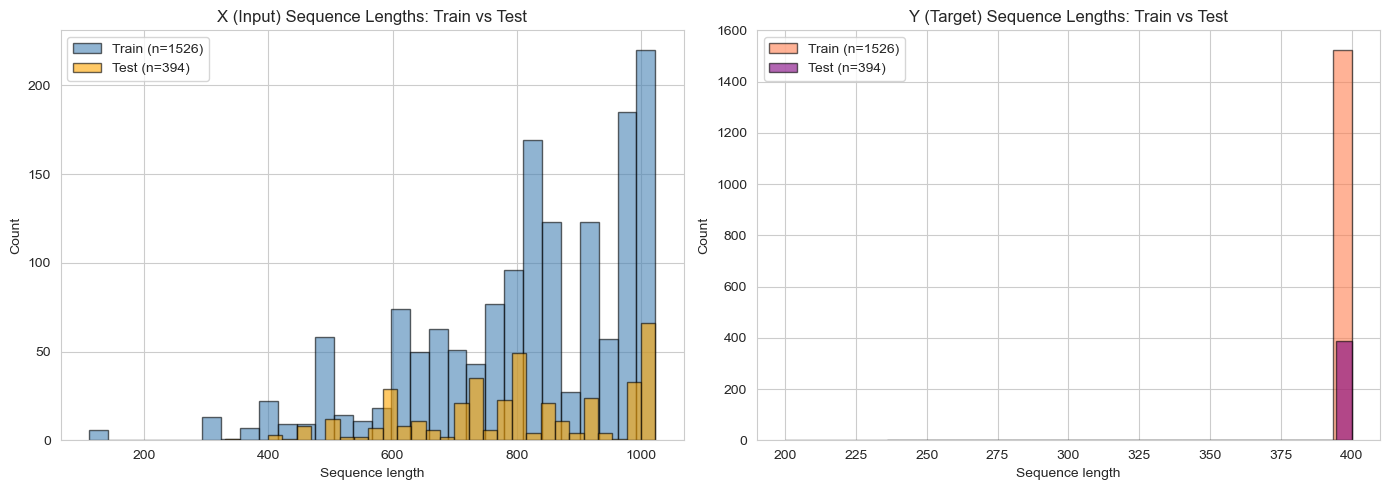

In [13]:
# Train vs Test sequence length distributions
if exists(train_path) and exists(test_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Input X
    axes[0].hist(seq_X_train, bins=30, alpha=0.6, label=f"Train (n={n_train})", color="steelblue", edgecolor="black")
    axes[0].hist(seq_X_test, bins=30, alpha=0.6, label=f"Test (n={n_test})", color="orange", edgecolor="black")
    axes[0].set_title("X (Input) Sequence Lengths: Train vs Test")
    axes[0].set_xlabel("Sequence length")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # Target Y
    axes[1].hist(seq_Y_train, bins=30, alpha=0.6, label=f"Train (n={n_train})", color="coral", edgecolor="black")
    axes[1].hist(seq_Y_test, bins=30, alpha=0.6, label=f"Test (n={n_test})", color="purple", edgecolor="black")
    axes[1].set_title("Y (Target) Sequence Lengths: Train vs Test")
    axes[1].set_xlabel("Sequence length")
    axes[1].set_ylabel("Count")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

---
# 5. Build Log — Sequence Lengths (from pipeline output)
Extract sequence length summary from the build log for cross-validation.

In [14]:
import re

log_path = join(OUTPUT_DIR, "process_chain_build.log")
if exists(log_path):
    with open(log_path, "r") as f:
        log_content = f.read()
    
    # Extract length lines
    length_pattern = re.compile(r"length_(\d+) count=(\d+)")
    
    # Find sections: input, target, source
    sections = {
        "input": "Flattening input sequence",
        "target": "Flattening target sequence",
        "source": "Flattening source sequence",
    }
    
    for sec_name, sec_marker in sections.items():
        idx = log_content.find(sec_marker)
        if idx == -1:
            continue
        # Find next section or end
        next_idx = len(log_content)
        for other_marker in sections.values():
            other_idx = log_content.find(other_marker, idx + len(sec_marker))
            if other_idx != -1 and other_idx < next_idx:
                next_idx = other_idx
        
        # Also check for other log sections
        for end_marker in ["Saved compressed", "Dataset generation", "Performing stratified"]:
            end_idx = log_content.find(end_marker, idx + len(sec_marker))
            if end_idx != -1 and end_idx < next_idx:
                next_idx = end_idx
        
        section_text = log_content[idx:next_idx]
        matches = length_pattern.findall(section_text)
        
        if matches:
            lengths = []
            for length, count in matches:
                lengths.extend([int(length)] * int(count))
            lengths = np.array(lengths)
            print(f"\n{sec_name.upper()} (from build log):")
            print(f"  Samples: {len(lengths)}, Min: {lengths.min()}, Max: {lengths.max()}, "
                  f"Mean: {lengths.mean():.1f}, Median: {np.median(lengths):.1f}")
else:
    print("Build log not found.")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xfc in position 119: invalid start byte

---
# 6. Paper-Ready Summary Table

In [ ]:
# Assemble a consolidated summary
summary = {}

summary["Build ID"] = dataset_id
summary["N samples"] = n_samples

# Train/test
if exists(train_path) and exists(test_path):
    summary["N train"] = n_train
    summary["N test"] = n_test
    summary["Train/Test ratio"] = f"{n_train/n_total*100:.1f}% / {n_test/n_total*100:.1f}%"

# Shapes
summary["X shape"] = str(X.shape)
if has_source:
    summary["S shape"] = str(S.shape)
summary["Y shape"] = str(Y.shape)

# Features
summary["N features (input)"] = X.shape[2]
if has_source:
    summary["N features (source)"] = S.shape[2]
summary["N features (target)"] = Y.shape[2]

# Vocabularies
summary["N processes"] = len(vocab_process) if vocab_process else "N/A"
summary["N variables (input)"] = len(vocab_var_input) if vocab_var_input else "N/A"
if vocab_var_source:
    summary["N variables (source)"] = len(vocab_var_source)
summary["N variables (target)"] = len(vocab_var_trg) if vocab_var_trg else "N/A"

# Sequence lengths — Input
summary["Input seq len (min)"] = int(np.min(seq_len_X))
summary["Input seq len (max)"] = int(np.max(seq_len_X))
summary["Input seq len (mean)"] = f"{np.mean(seq_len_X):.1f}"
summary["Input seq len (median)"] = f"{np.median(seq_len_X):.1f}"

# Sequence lengths — Source
if has_source:
    summary["Source seq len (min)"] = int(np.min(seq_len_S))
    summary["Source seq len (max)"] = int(np.max(seq_len_S))
    summary["Source seq len (mean)"] = f"{np.mean(seq_len_S):.1f}"
    summary["Source seq len (median)"] = f"{np.median(seq_len_S):.1f}"

# Sequence lengths — Target
summary["Target seq len (min)"] = int(np.min(seq_len_Y))
summary["Target seq len (max)"] = int(np.max(seq_len_Y))
summary["Target seq len (mean)"] = f"{np.mean(seq_len_Y):.1f}"
summary["Target seq len (median)"] = f"{np.median(seq_len_Y):.1f}"

# Missing values
summary["Input missing % (excl. padding)"] = stats_X["Missing %"]
if has_source:
    summary["Source missing % (excl. padding)"] = stats_S["Missing %"]
summary["Target missing % (excl. padding)"] = stats_Y["Missing %"]

# Display
df_summary = pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])
df_summary.index.name = "Metric"

print("=" * 60)
print("PAPER-READY SUMMARY")
print("=" * 60)
display(df_summary)

In [ ]:
# Export summary to CSV (for easy copy-paste into papers)
summary_path = join(OUTPUT_DIR, "build_summary.csv")
df_summary.to_csv(summary_path)
print(f"Summary exported to: {summary_path}")